In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

ROOT = Path("/home/py/groundwater/")
DATA = ROOT / 'data'
GOWN = DATA / 'gown'

In [3]:
def z_norm(s):
    return (s - s.mean()) / s.std()

In [4]:
df = pd.read_csv(GOWN / 'combined_absval_20052024_filled.csv', parse_dates=[0], index_col=0)
df = df.sort_index(axis=1)
df.columns = df.columns.astype(int)

brac = pd.read_csv(DATA / 'bow_valley' / 'stream' / 'cr_flow.csv', index_col=1, parse_dates=[1])
brac = brac.drop(columns=['Unnamed: 0'])
brac = brac.loc['2005':]
brac = brac.squeeze()

krns = pd.read_csv(DATA / 'bow_valley' / 'stream' / 'krns_daily.csv', index_col=0, parse_dates=[0])
krns = krns.squeeze()

mcreek = [931, 301, 303, 386, 305]
canmore = [764, 760, 759, 364]

In [5]:
df_z = df.apply(z_norm)

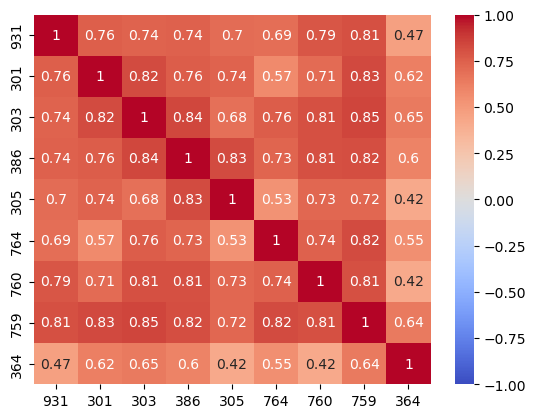

In [6]:
corr = df_z[mcreek+canmore].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.show()

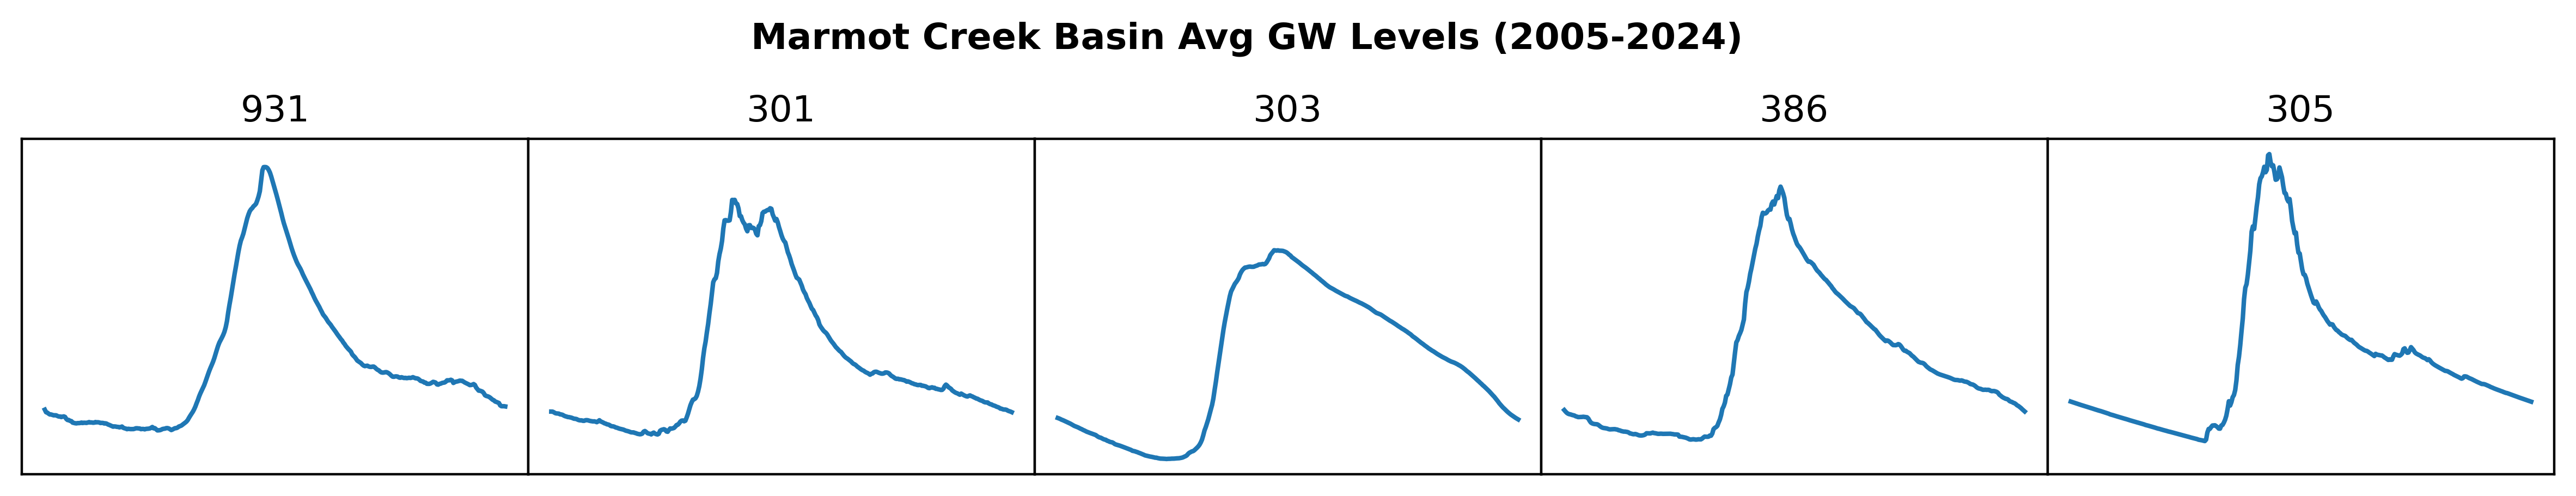

In [39]:
fig, axes = plt.subplots(1, 5, figsize=(15,2), dpi=400, sharey=True)
plt.suptitle("Marmot Creek Basin Avg GW Levels (2005-2024)", y=1.15, fontweight='bold')
for i, w in enumerate(mcreek):
    x = z_norm(df[w].groupby(df[w].index.strftime('%m-%d')).mean().drop('02-29'))
    axes[i].plot(x.index, x)
    axes[i].set_xticks([])
    axes[i].set_yticks([])
    axes[i].set_title(f"{w}")
plt.subplots_adjust(wspace=0)

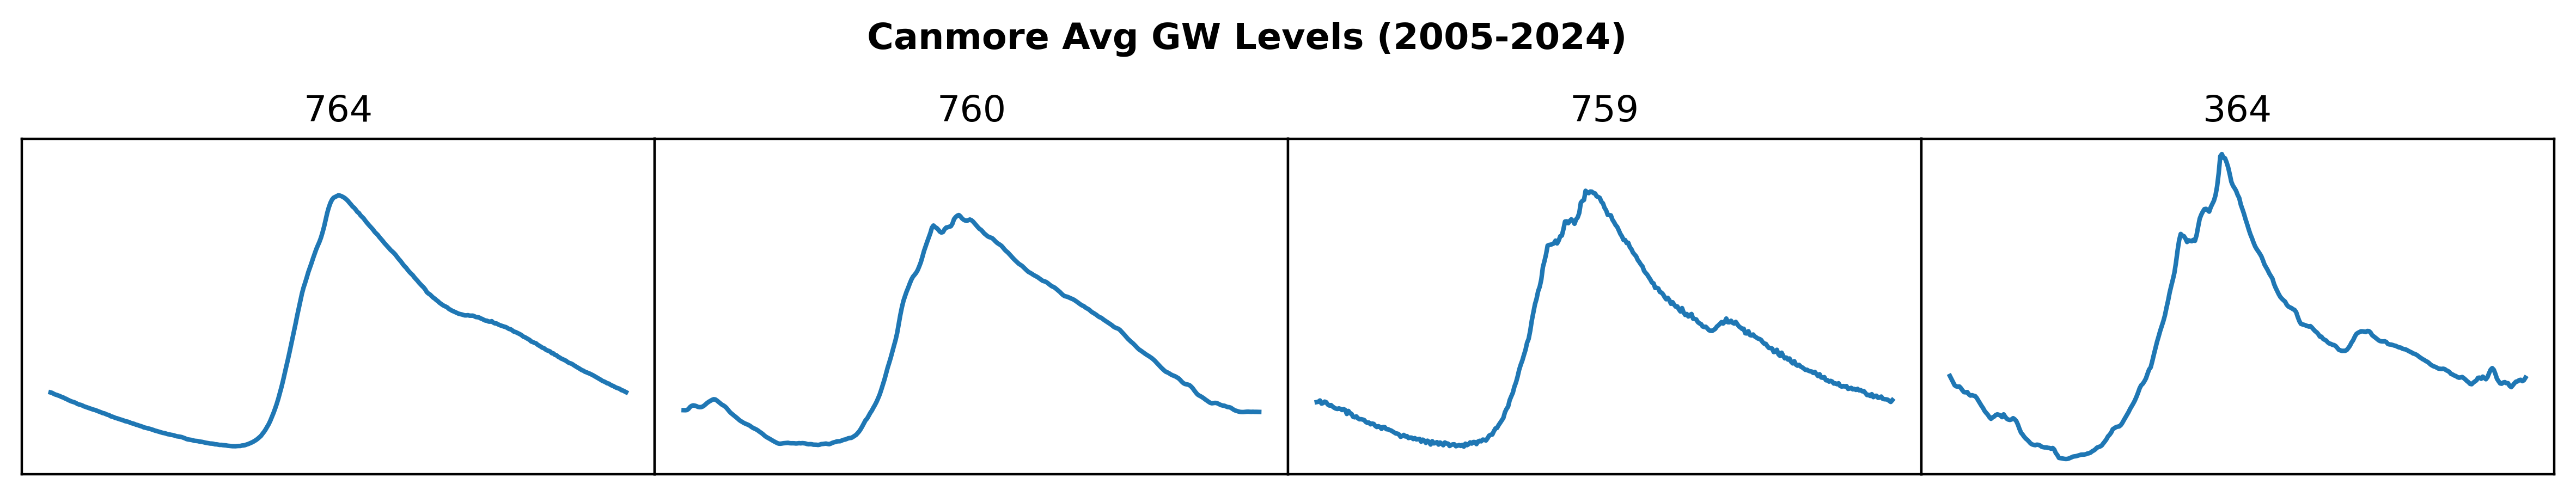

In [40]:
fig, axes = plt.subplots(1, 4, figsize=(15,2), dpi=400, sharey=True)
plt.suptitle("Canmore Avg GW Levels (2005-2024)", y=1.15, fontweight='bold')
for i, w in enumerate(canmore):
    x = z_norm(df[w].groupby(df[w].index.strftime('%m-%d')).mean().drop('02-29'))
    axes[i].plot(x.index, x)
    axes[i].set_xticks([])
    axes[i].set_yticks([])
    axes[i].set_title(f"{w}")
plt.subplots_adjust(wspace=0)
plt.show()

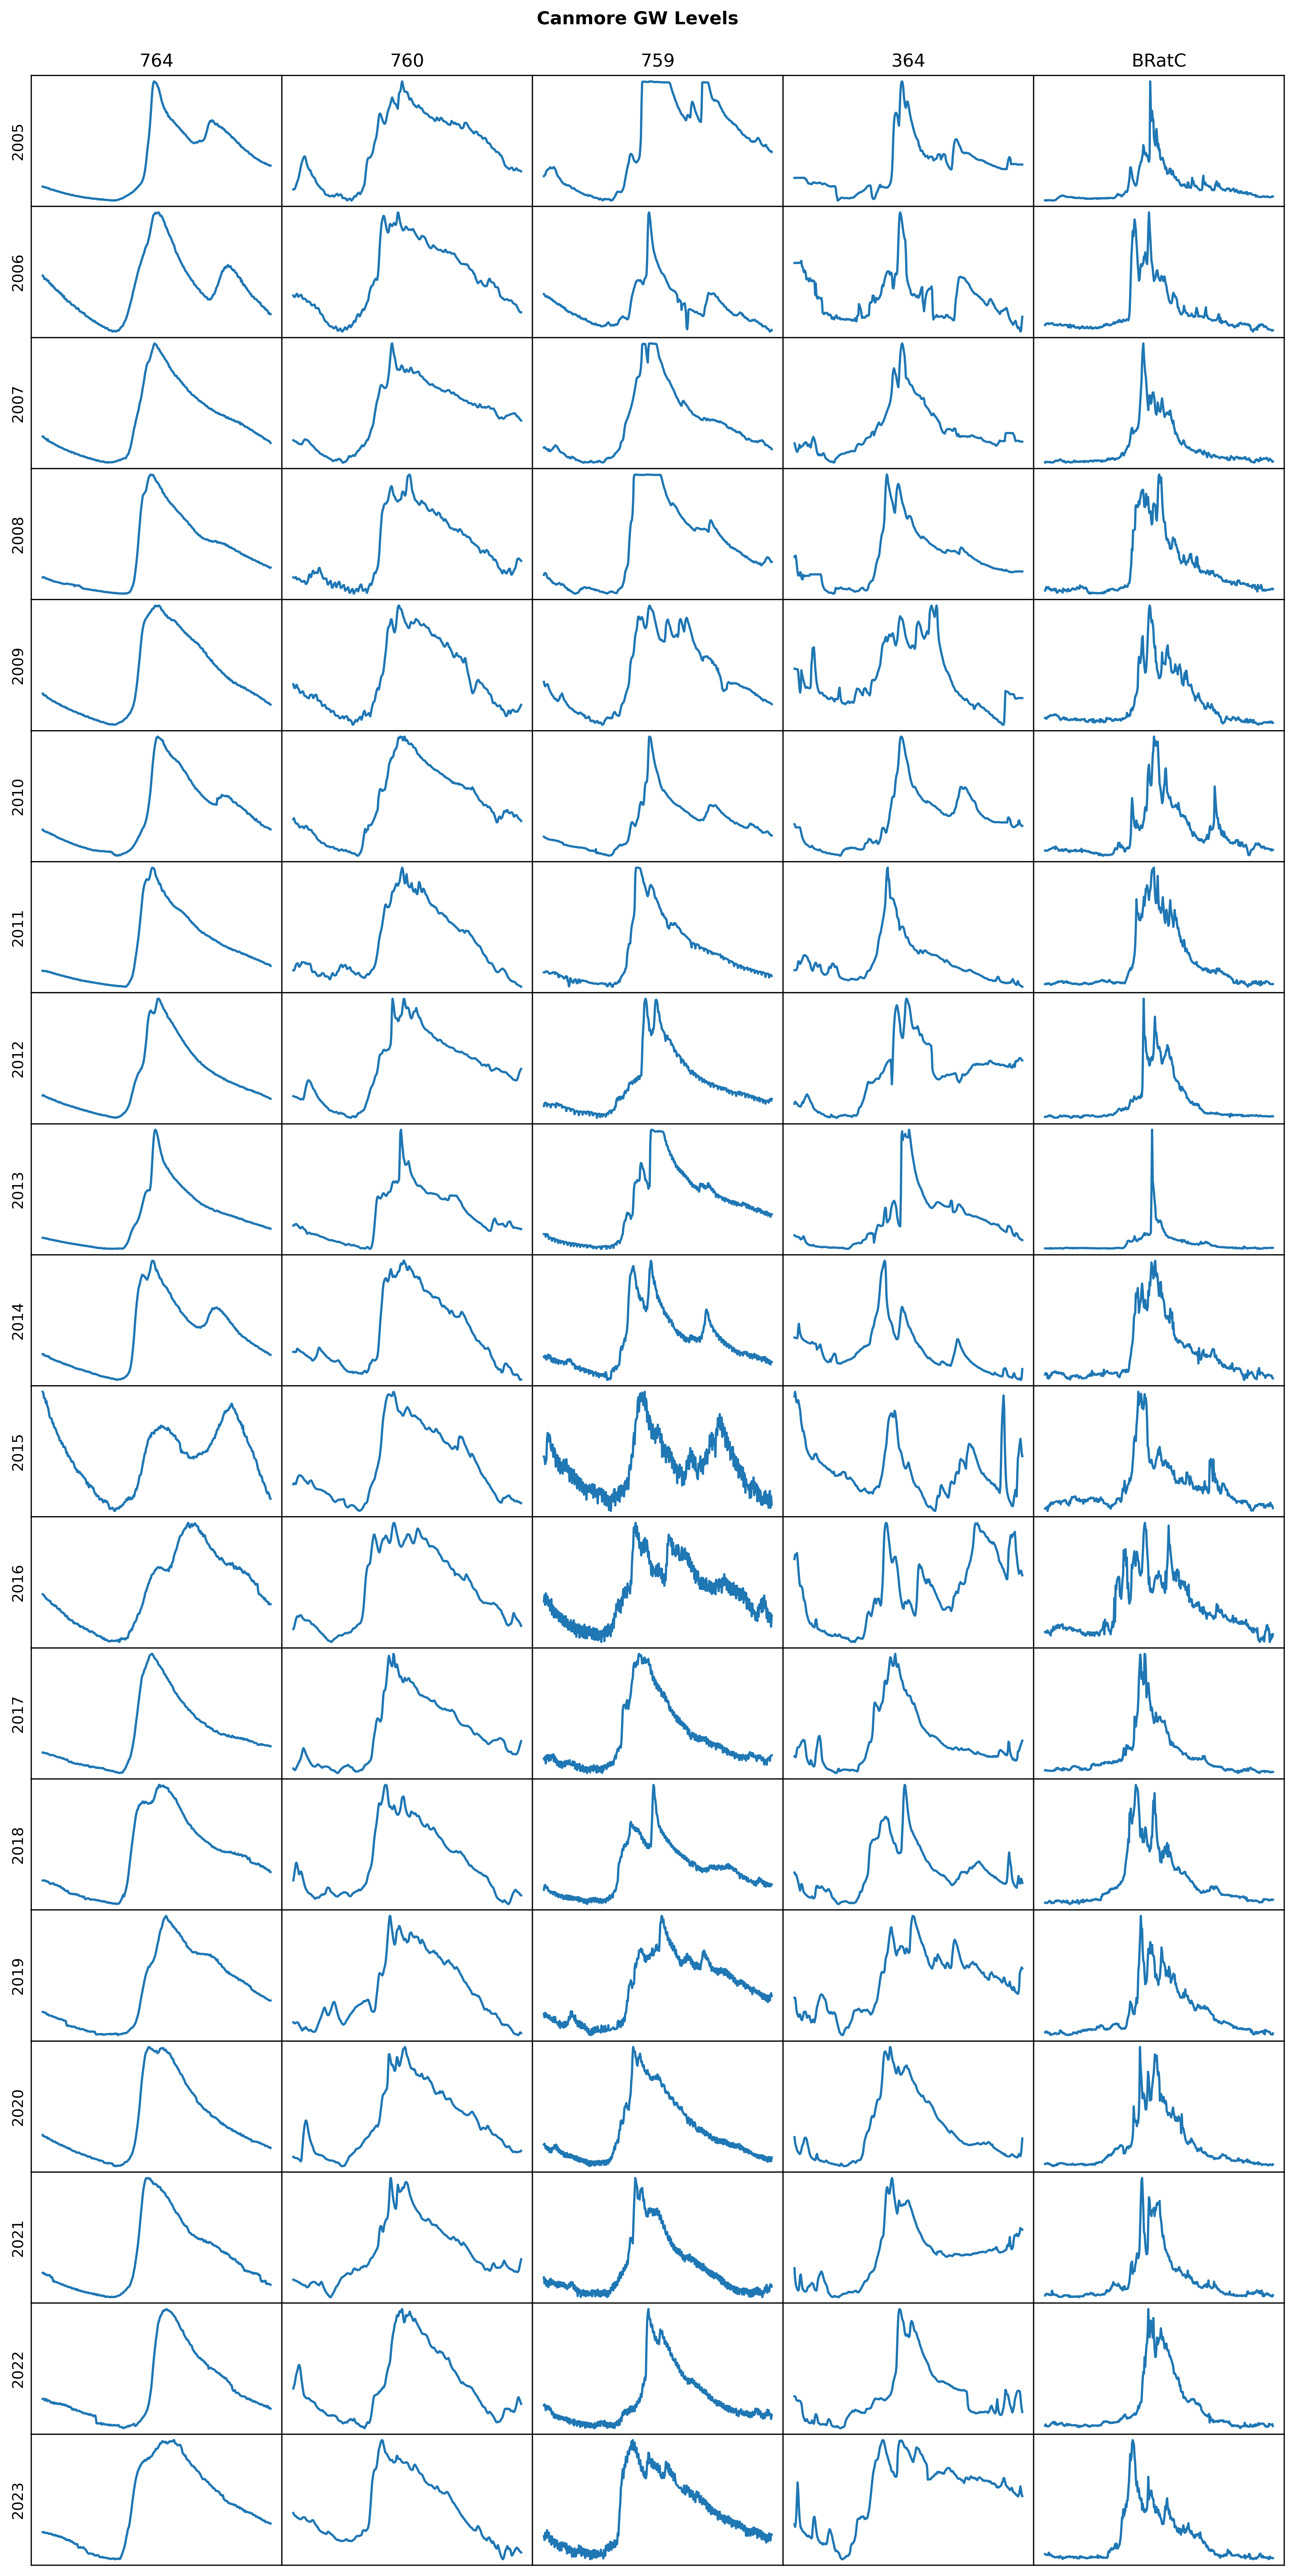

In [9]:
fig, axes = plt.subplots(19, 5, figsize=(15,30), dpi=400)
for row, y in enumerate(range(2005, 2024)):
    for i, w in enumerate(canmore):
        if i == 0: axes[row, i].set_ylabel(y, rotation=90)
        x = z_norm(df[w].loc[f'{y}'])
        axes[row, i].plot(x.index, x)
        axes[row ,i].set_xticks([])
        axes[row, i].set_yticks([])
        if row == 0: axes[row, i].set_title(f"{w}")

    x = z_norm(brac.loc[f'{y}'])
    axes[row, 4].plot(x.index, x)
    axes[row ,4].set_xticks([])
    axes[row, 4].set_yticks([])
    if row == 0: axes[row, 4].set_title("BRatC")

plt.suptitle(f"Canmore GW Levels", fontweight='bold', y=0.9)
plt.subplots_adjust(wspace=0, hspace=0)
plt.show()

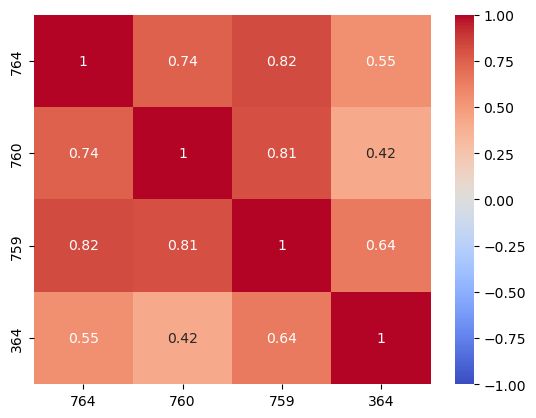

In [10]:
corr = df_z[canmore].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.show()

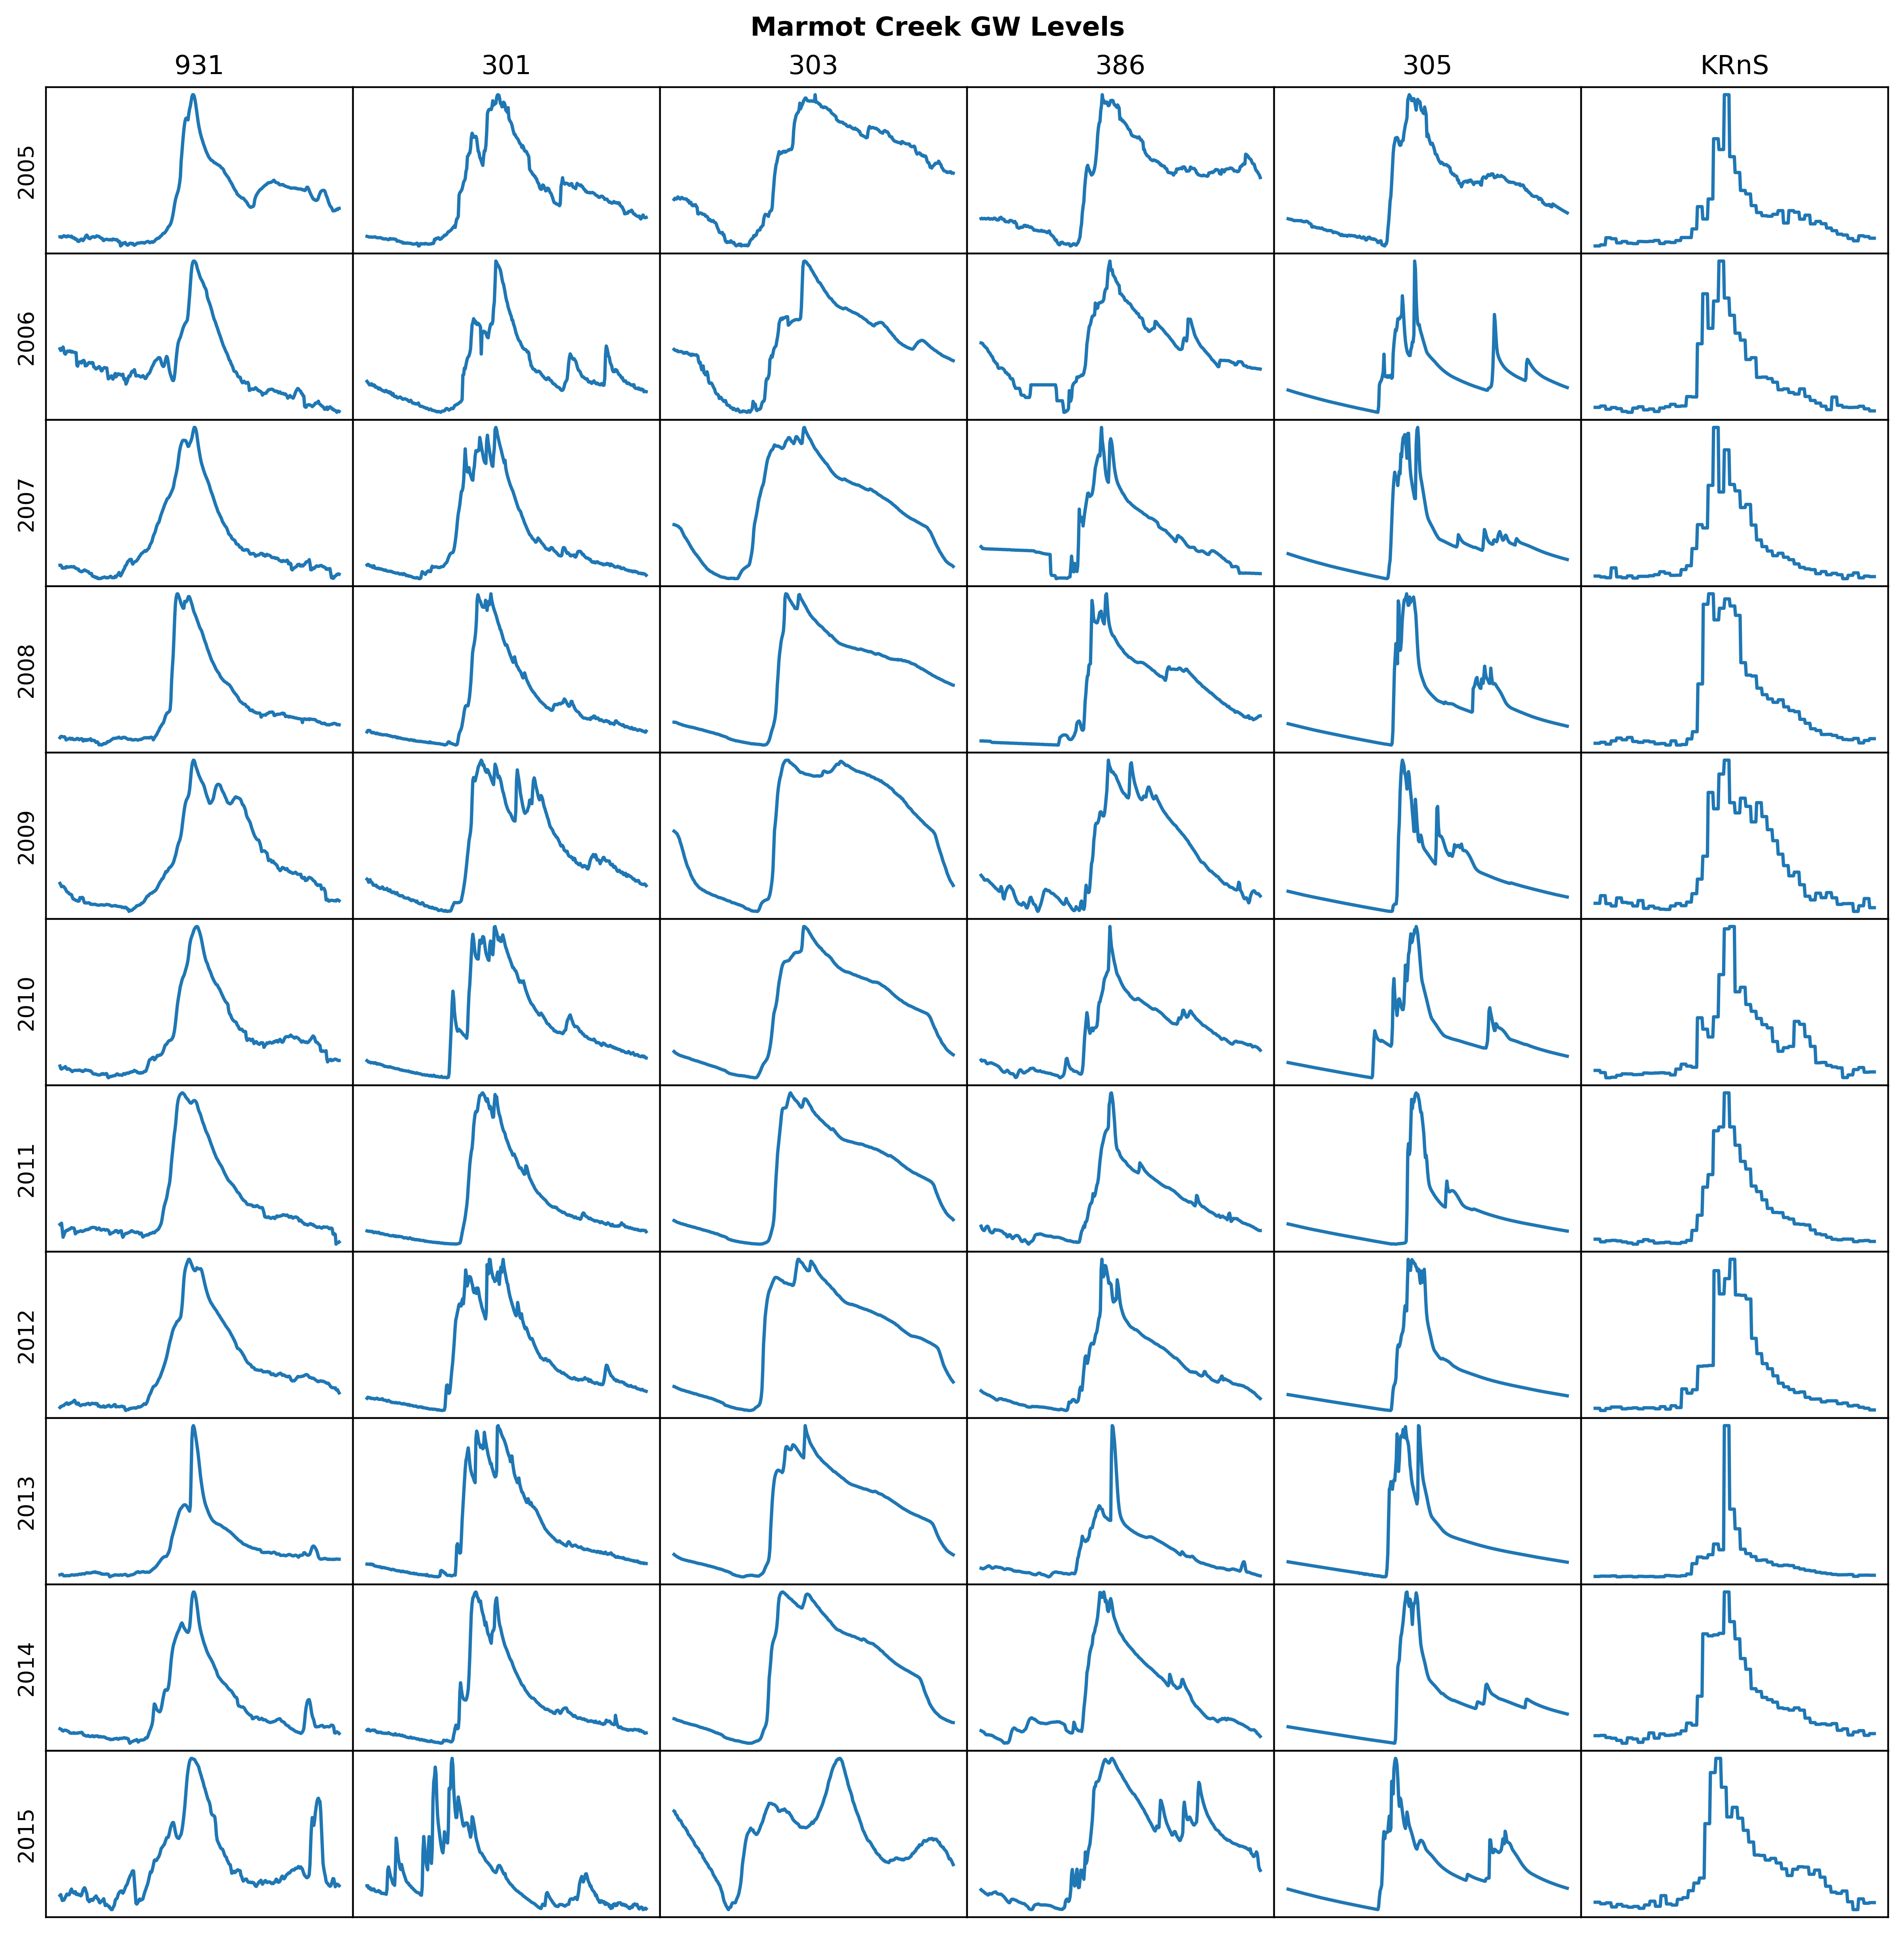

In [11]:
fig, axes = plt.subplots(11, 6, figsize=(15,15), dpi=400)
for row, y in enumerate(range(2005, 2016)):
    for i, w in enumerate(mcreek):
        if i == 0: axes[row, i].set_ylabel(y, rotation=90)
        x = z_norm(df[w].loc[f'{y}'])
        axes[row, i].plot(x.index, x)
        axes[row ,i].set_xticks([])
        axes[row, i].set_yticks([])
        if row == 0: axes[row, i].set_title(f"{w}")

    x = z_norm(krns.loc[f'{y}'])
    axes[row, 5].plot(x.index, x)
    axes[row ,5].set_xticks([])
    axes[row, 5].set_yticks([])
    if row == 0: axes[row, 5].set_title("KRnS")

plt.suptitle(f"Marmot Creek GW Levels", fontweight='bold', y=0.91)
plt.subplots_adjust(wspace=0, hspace=0)
plt.show()

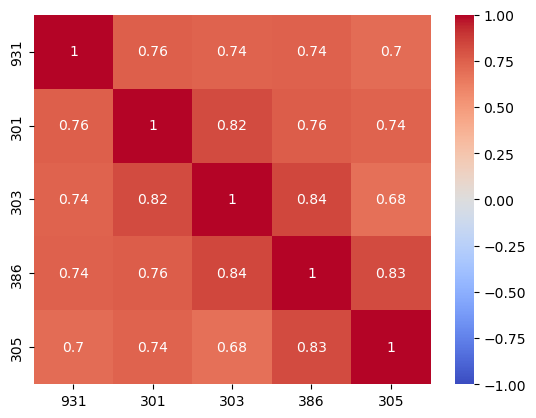

In [12]:
corr = df_z[mcreek].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.show()

In [13]:
from scipy.stats import linregress

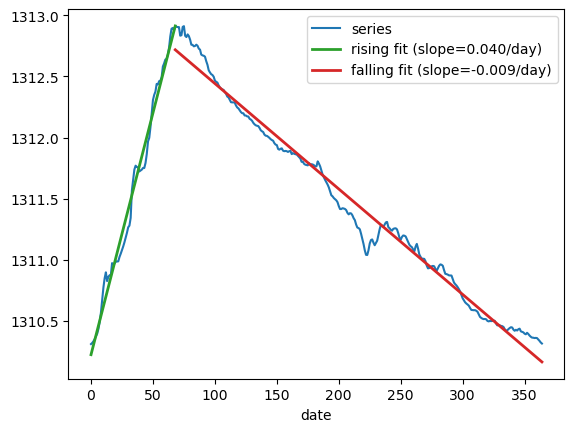

In [14]:
s = df[760].loc['2010']

i_trough = s.idxmin()
s_shifted = s.copy()
s_shifted.index = (s.index - i_trough) / np.timedelta64(1, 'D')

pos   = s_shifted.index.get_loc(0) # trough sits at day 0
front = s_shifted.iloc[pos:]
back  = s_shifted.iloc[:pos].copy()
back.index = back.index + 365
s_loop = pd.concat([front, back])

i_peak  = s_loop.idxmax()
rising  = s_loop.loc[:i_peak]
falling = s_loop.loc[i_peak:]

r_fit = linregress(rising.index,  rising.values) 
f_fit = linregress(falling.index, falling.values)

fig, ax = plt.subplots()
s_loop.plot(ax=ax, label='series')
for seg, fit, color, label in [
    (rising,  r_fit, 'tab:green', 'rising fit'),
    (falling, f_fit, 'tab:red',  'falling fit'),
]:
    t = seg.index.values
    ax.plot(t, fit.intercept + fit.slope * t, color=color, lw=2,
            label=f'{label} (slope={fit.slope:.3f}/day)')
ax.legend()
plt.show()

In [48]:
def plot_slope_fit(s, title=""):
    i_trough = s.idxmin()
    s_shifted = s.copy()
    s_shifted.index = (s.index - i_trough) / np.timedelta64(1, 'D')

    pos   = s_shifted.index.get_loc(0) # trough sits at day 0
    front = s_shifted.iloc[pos:]
    back  = s_shifted.iloc[:pos].copy()
    back.index = back.index + 365
    s_loop = pd.concat([front, back])

    i_peak  = s_loop.idxmax()
    rising  = s_loop.loc[:i_peak]
    falling = s_loop.loc[i_peak:]

    r_fit = linregress(rising.index,  rising.values) 
    f_fit = linregress(falling.index, falling.values)

    fig, ax = plt.subplots()
    s_loop.plot(ax=ax, label='series')
    for seg, fit, color, label in [
        (rising,  r_fit, 'tab:green', 'rising fit'),
        (falling, f_fit, 'tab:red',  'falling fit'),
    ]:
        t = seg.index.values
        ax.plot(t, fit.intercept + fit.slope * t, color=color, lw=2,
                label=f'{label} (slope={fit.slope:.3f}/day)')
    ax.legend()
    plt.title(title, fontweight='bold')
    plt.show()

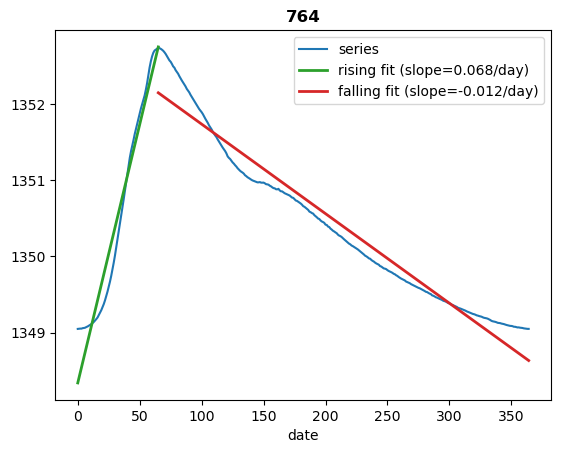

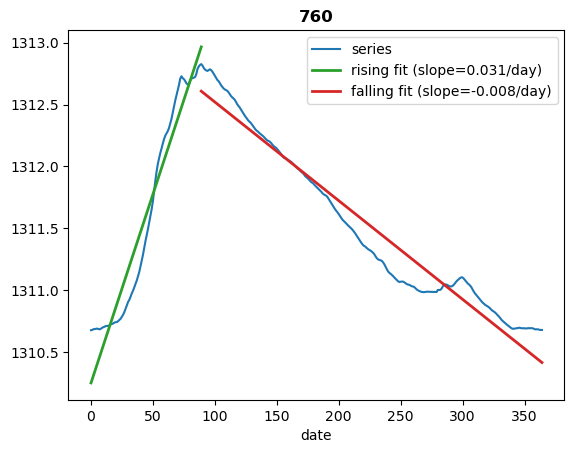

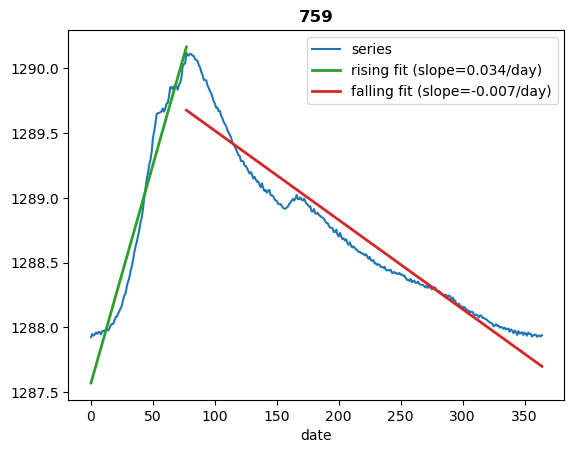

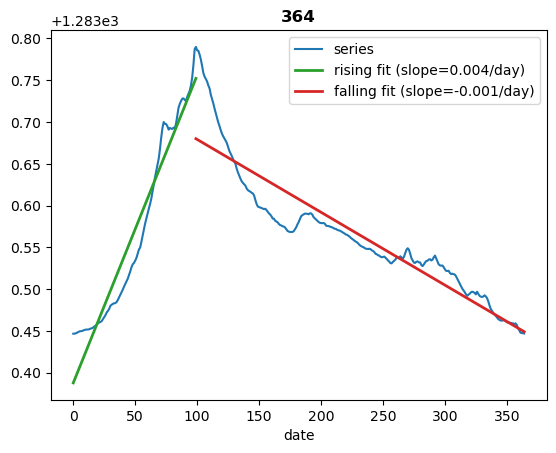

In [47]:
for w in canmore:
    s = df[w].groupby(df[w].index.strftime('%m-%d')).mean().drop('02-29')
    s.index = pd.to_datetime('2001-' + s.index, format='%Y-%m-%d')
    plot_slope_fit(s, w)

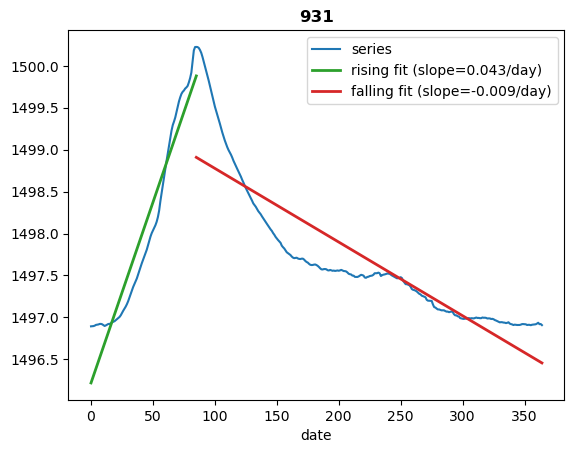

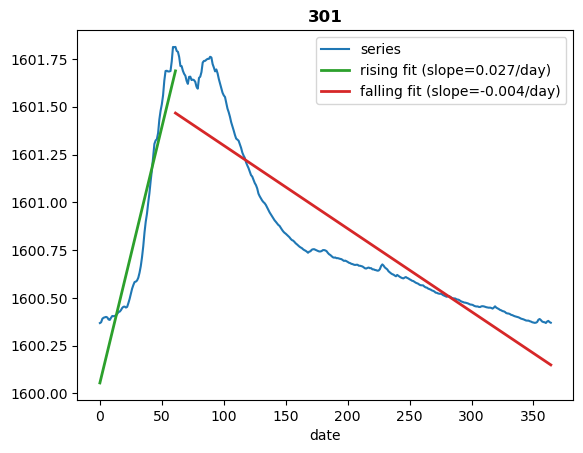

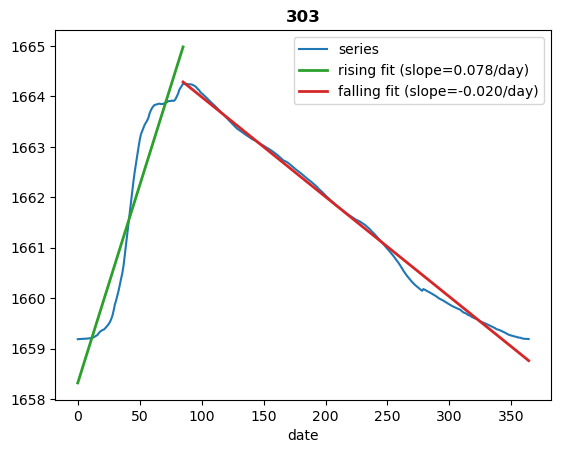

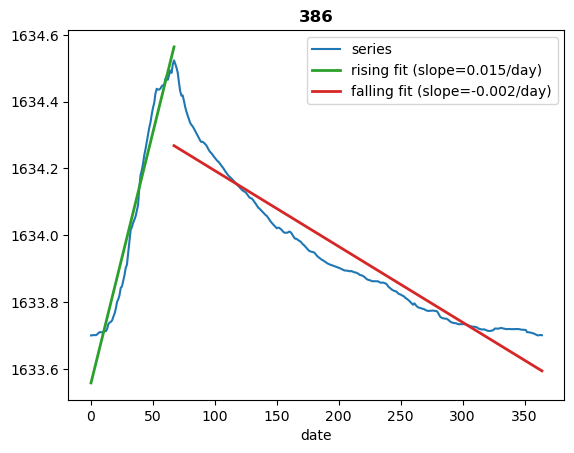

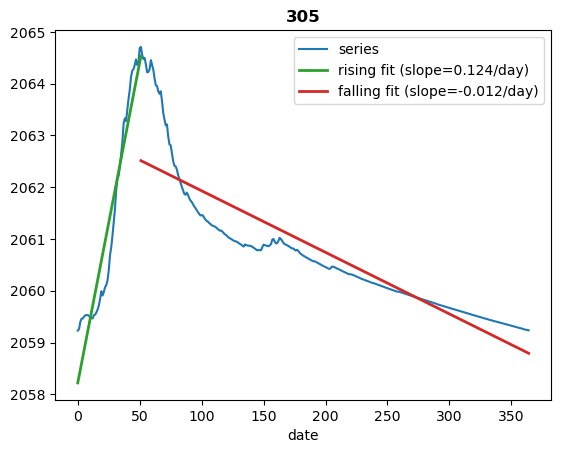

In [49]:
for w in mcreek:
    s = df[w].groupby(df[w].index.strftime('%m-%d')).mean().drop('02-29')
    s.index = pd.to_datetime('2001-' + s.index, format='%Y-%m-%d')
    plot_slope_fit(s, w)

In [50]:
from scipy.optimize import curve_fit

In [51]:
def recession_exp(t, h_inf, amp, tau):
    return h_inf + amp * np.exp(-t / tau)

In [62]:
def plot_fit(s, title=""):
    i_trough = s.idxmin()
    s_shifted = s.copy()
    s_shifted.index = (s.index - i_trough) / np.timedelta64(1, 'D')

    pos   = s_shifted.index.get_loc(0) # trough sits at day 0
    front = s_shifted.iloc[pos:]
    back  = s_shifted.iloc[:pos].copy()
    back.index = back.index + 365
    s_loop = pd.concat([front, back])

    i_peak  = s_loop.idxmax()
    rising  = s_loop.loc[:i_peak]
    falling = s_loop.loc[i_peak:]

    r_fit = linregress(rising.index,  rising.values) 

    t_fall = falling.index.values - falling.index.values[0]
    p0 = [falling.min(), falling.values[0] - falling.min(), 60]  # baseline, drop, tau
    f_popt, _ = curve_fit(recession_exp, t_fall, falling.values, p0=p0,
                          bounds=([-np.inf, 0, 0], [np.inf, np.inf, np.inf]))
    h_inf, amp, tau = f_popt

    fig, ax = plt.subplots()
    s_loop.plot(ax=ax, label='series')
    r_pred = r_fit.intercept + r_fit.slope * rising.index.values
    f_pred = recession_exp(t_fall, *f_popt)          # evaluated at t_fall...

    for seg, pred, color, label in [
        (rising,  r_pred, 'tab:green', f'rising fit (slope={r_fit.slope:.3f}/day)'),
        (falling, f_pred, 'tab:red',   f'falling fit (τ={tau:.0f} d)'),
    ]:
        ax.plot(seg.index.values, pred, color=color, lw=2, label=label)
    ax.legend()
    plt.title(title, fontweight='bold')
    plt.show()

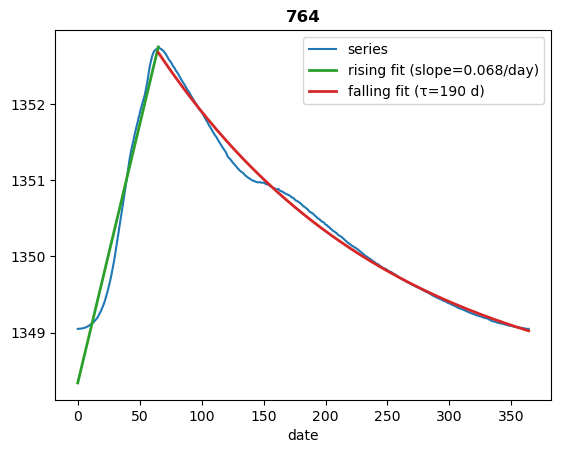

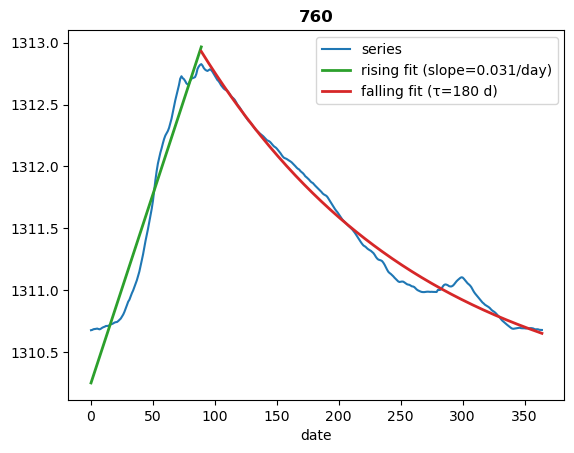

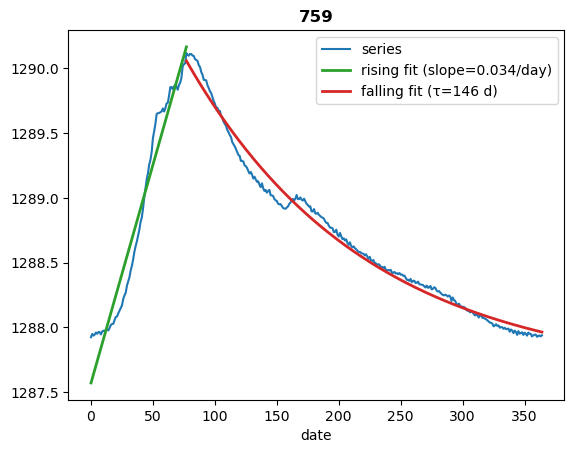

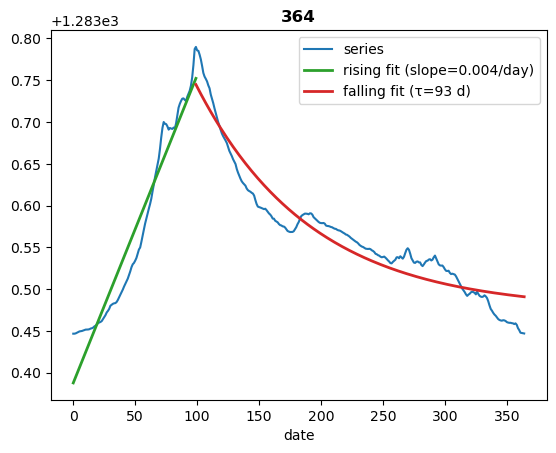

In [63]:
for w in canmore:
    s = df[w].groupby(df[w].index.strftime('%m-%d')).mean().drop('02-29')
    s.index = pd.to_datetime('2001-' + s.index, format='%Y-%m-%d')
    plot_fit(s, w)

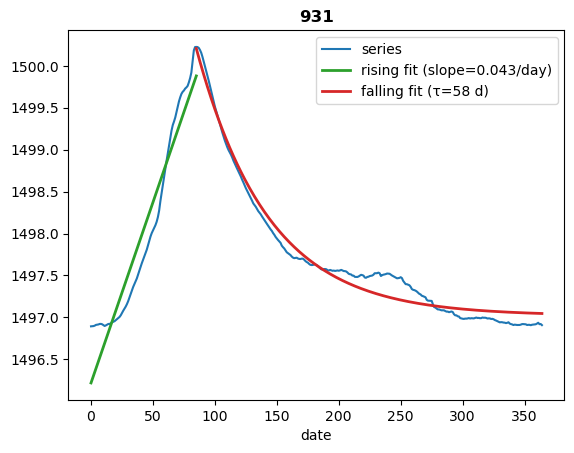

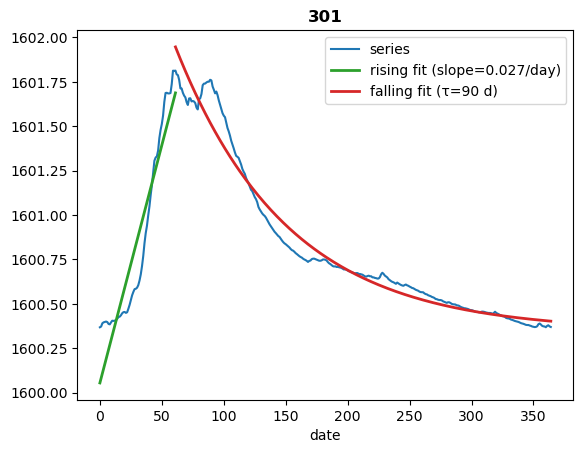

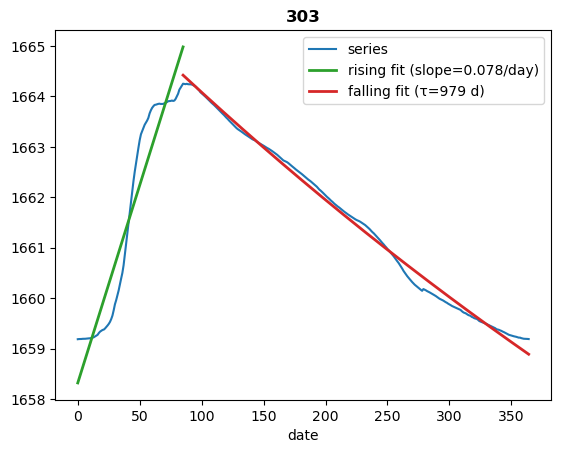

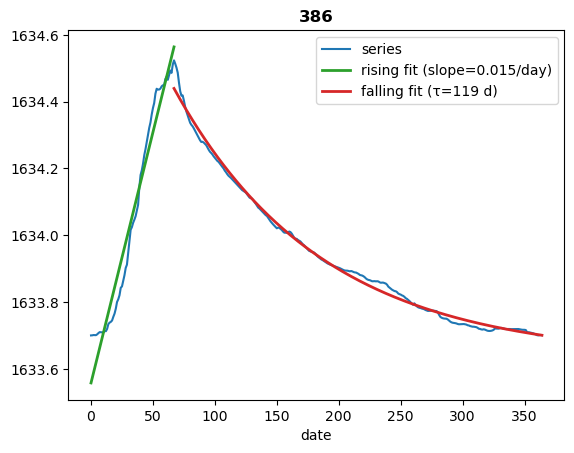

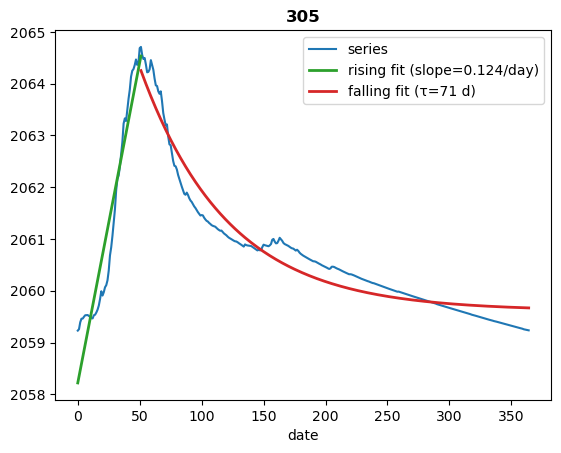

In [54]:
for w in mcreek:
    s = df[w].groupby(df[w].index.strftime('%m-%d')).mean().drop('02-29')
    s.index = pd.to_datetime('2001-' + s.index, format='%Y-%m-%d')
    plot_fit(s, w)

In [55]:
def fit_cycle(s, year, well, band=('03','07'), smooth=7, min_cov=0.8):
    ss = s.rolling(smooth, center=True, min_periods=1).mean()   # locate extrema on this
    try:
        lo = ss.loc[f'{year}-{band[0]}':f'{year}-{band[1]}'].dropna()
        hi = ss.loc[f'{year+1}-{band[0]}':f'{year+1}-{band[1]}'].dropna()
        if lo.empty or hi.empty:
            return None
        t0, t1 = lo.idxmin(), hi.idxmin()          # cycle endpoints = the two troughs
        cyc = s.loc[t0:t1].dropna()                # RAW values for fitting
        if len(cyc) < min_cov * ((t1 - t0).days + 1):   # skip incomplete years
            return None

        t = np.asarray((cyc.index - t0) / np.timedelta64(1, 'D'))     # days since trough
        peak_day = (ss.loc[t0:t1].idxmax() - t0) / np.timedelta64(1, 'D')
        rise = t <= peak_day

        r_fit = linregress(t[rise], cyc.values[rise])

        tf = t[~rise] - peak_day                   # days since peak
        hf = cyc.values[~rise]
        p0 = [hf.min(), hf[0] - hf.min(), 60]
        popt, _ = curve_fit(recession_exp, tf, hf, p0=p0,
                            bounds=([-np.inf,0,0],[np.inf,np.inf,np.inf]), maxfev=5000)
        h_inf, amp, tau = popt
        exp_r2 = 1 - np.sum((hf-recession_exp(tf,*popt))**2)/np.sum((hf-hf.mean())**2)

        return dict(well=well, year=year, rise_slope=r_fit.slope, rise_r2=r_fit.rvalue**2,
                    tau=tau, exp_r2=exp_r2, window=(t1-t0).days, peak_day=peak_day, n=len(cyc))
    except (RuntimeError, ValueError):
        return None

In [80]:
wells = canmore + mcreek
years = range(df.index.year.min(), df.index.year.max())   # last year can't close a cycle
rows  = [fit_cycle(df[w], y, w) for w in wells for y in years]
res   = pd.DataFrame([r for r in rows if r is not None])

In [81]:
res

,well,year,rise_slope,rise_r2,tau,exp_r2,window,peak_day,n
0,764,2005,0.077386,0.676858,916.299635,0.910009,367,68.0,368
1,764,2006,0.043181,0.980364,948.956332,0.879455,355,69.0,356
2,764,2007,0.057139,0.891653,167.495249,0.995775,388,76.0,389
3,764,2008,0.155632,0.916505,136.737229,0.993528,353,47.0,354
4,764,2009,0.065163,0.907376,192.295500,0.997129,371,69.0,372
...,...,...,...,...,...,...,...,...,...
166,305,2019,0.351654,0.877914,75.336824,0.954631,371,23.0,372
167,305,2020,0.400662,0.966968,61.896384,0.935395,362,23.0,363
168,305,2021,0.361876,0.921517,79.924329,0.940321,378,22.0,379
169,305,2022,0.519334,0.873875,49.728051,0.934921,339,19.0,340


In [82]:
from matplotlib.ticker import FixedLocator, ScalarFormatter

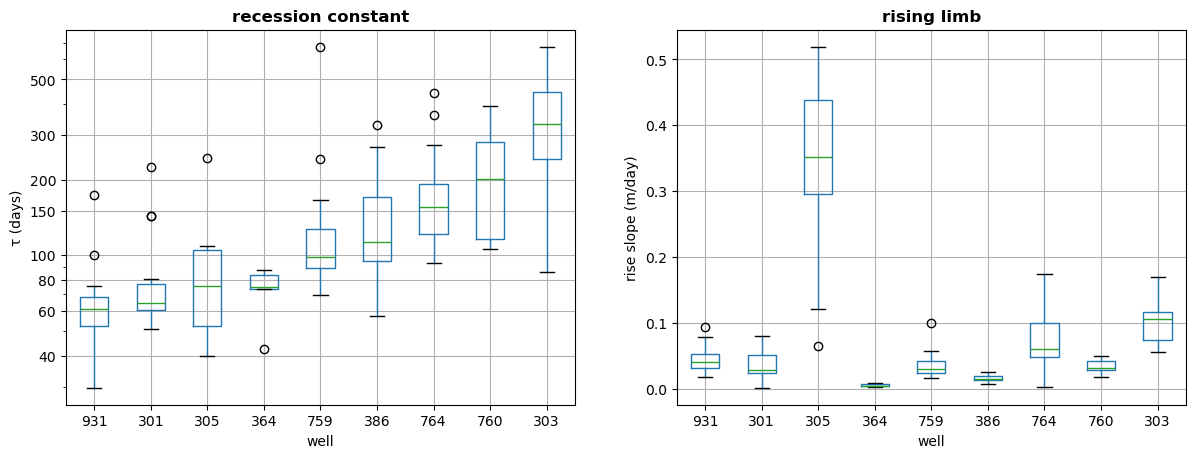

In [83]:
res['well'] = pd.Categorical(res.well,
    categories=res.groupby('well').tau.median().sort_values().index, ordered=True)  # fast→slow order

res = res[(res.exp_r2 > 0.9) & (res.tau < 2 * res.window)]

fig, ax = plt.subplots(1, 2, figsize=(14,5))

res.boxplot(column='tau', by='well', ax=ax[0])

ax[0].set_yscale('log')
ax[0].set_ylabel('τ (days)')
ax[0].set_title('recession constant', fontweight='bold')

ticks = [40, 60, 80, 100, 150, 200, 300, 500]
ax[0].yaxis.set_major_locator(FixedLocator(ticks))
ax[0].yaxis.set_major_formatter(ScalarFormatter())

res.boxplot(column='rise_slope', by='well', ax=ax[1])

ax[1].set_ylabel('rise slope (m/day)')
ax[1].set_title('rising limb', fontweight='bold')

plt.suptitle('')
plt.show()

In [76]:
def plot_semilog(s, title=""):
    # --- identical to plot_fit up through `falling` ---
    i_trough = s.idxmin()
    s_shifted = s.copy()
    s_shifted.index = (s.index - i_trough) / np.timedelta64(1, 'D')

    pos   = s_shifted.index.get_loc(0)
    front = s_shifted.iloc[pos:]
    back  = s_shifted.iloc[:pos].copy()
    back.index = back.index + 365
    s_loop = pd.concat([front, back])

    i_peak  = s_loop.idxmax()
    falling = s_loop.loc[i_peak:]

    # --- exponential fit (rising limb not needed here) ---
    t_fall = falling.index.values - falling.index.values[0]   # 0 at the peak
    p0 = [falling.min(), falling.values[0] - falling.min(), 60]
    f_popt, _ = curve_fit(recession_exp, t_fall, falling.values, p0=p0,
                          bounds=([-np.inf, 0, 0], [np.inf, np.inf, np.inf]))
    h_inf, amp, tau = f_popt

    # --- semilog diagnostic ---
    resid = falling.values - h_inf
    mask  = resid > 0                        # log drops non-positive points; make it explicit
    fig, ax = plt.subplots()
    ax.semilogy(t_fall[mask], resid[mask], '.', label='data')
    ax.semilogy(t_fall, amp * np.exp(-t_fall / tau), 'r-',
                label=f'single-exp (τ={tau:.0f} d)')
    ax.set_xlabel('days since peak'); ax.set_ylabel('head above baseline (log)')
    ax.legend(); plt.title(title, fontweight='bold'); plt.show()

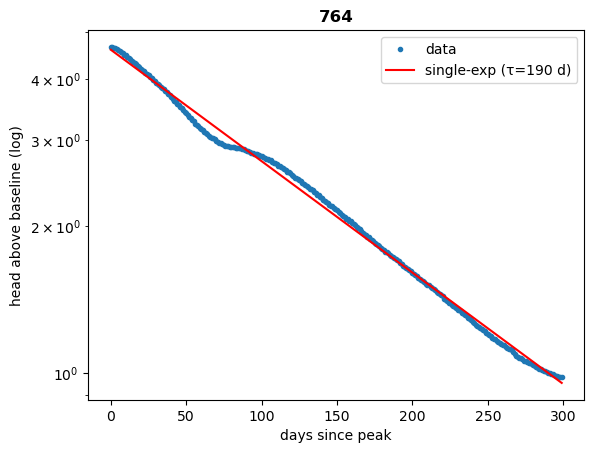

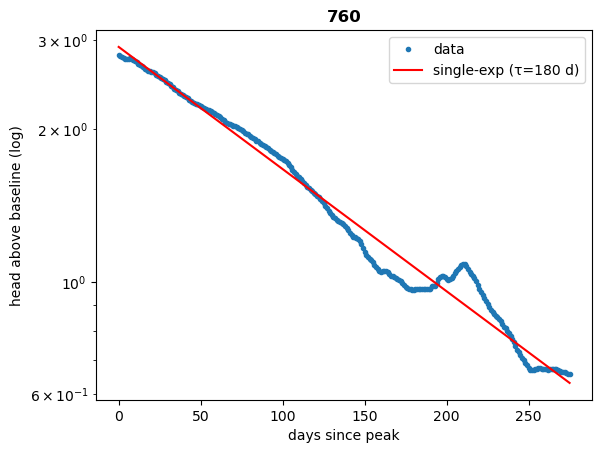

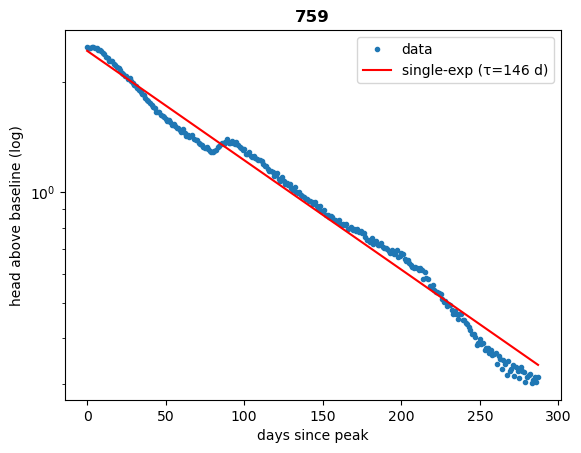

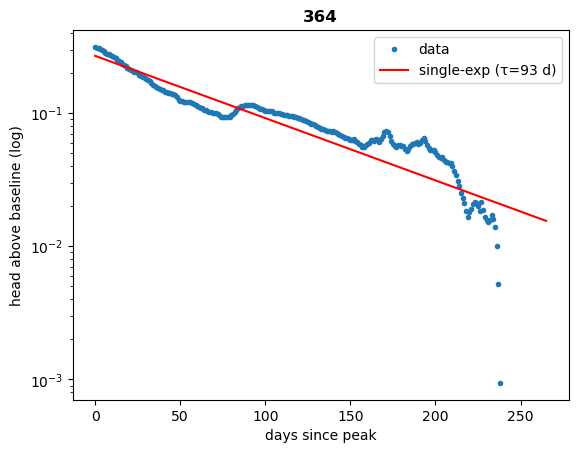

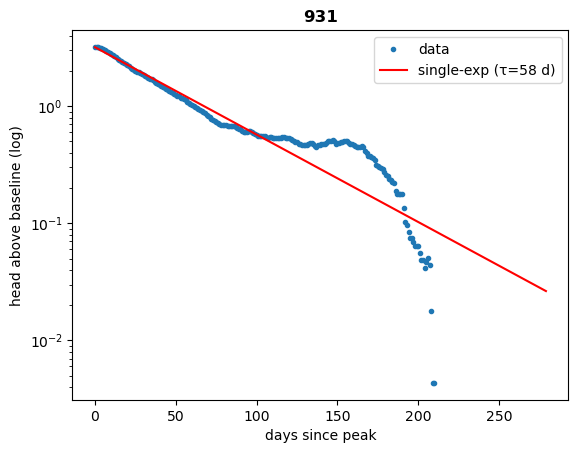

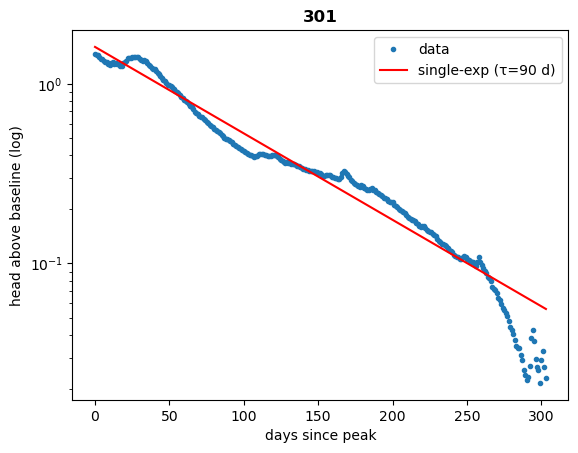

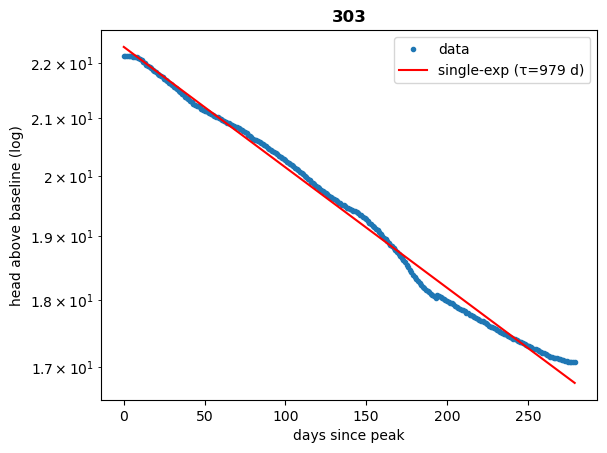

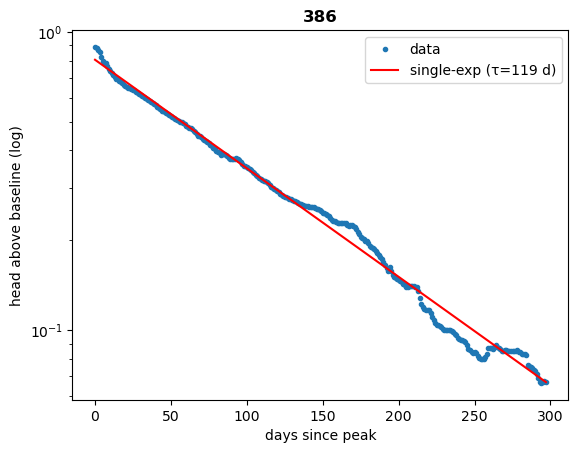

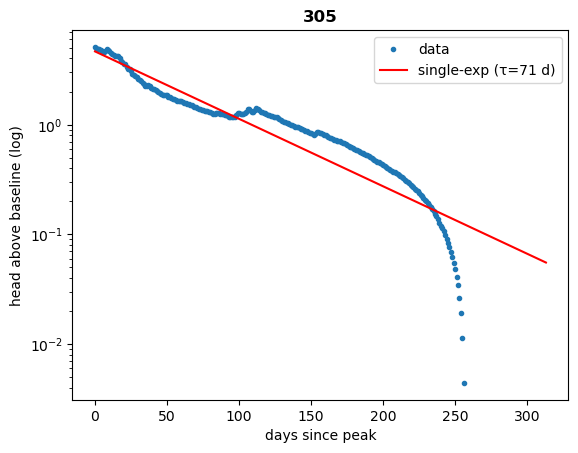

In [67]:
for w in canmore+mcreek:
    s = df[w].groupby(df[w].index.strftime('%m-%d')).mean().drop('02-29')
    s.index = pd.to_datetime('2001-' + s.index, format='%Y-%m-%d')
    plot_semilog(s, w)